## Clone the repo + enter the dir

In [1]:
# Go back to root
%cd /content


# Clone fresh
!git clone https://github.com/zohir22s/cifar10-ann-cnn-comparison.git

# Enter the directory
%cd cifar10-ann-cnn-comparison

# Create the missing __init__.py files
!touch data/__init__.py
!touch models/__init__.py
!touch training/__init__.py
!touch evaluation/__init__.py
# Test imports
from data.load_data import train_loader, test_loader
from models.ann_model import ANN
print("✅ All imports successful!")

/content
Cloning into 'cifar10-ann-cnn-comparison'...
remote: Enumerating objects: 224, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 224 (delta 6), reused 18 (delta 4), pack-reused 195 (from 1)
Receiving objects: 100% (224/224), 54.37 MiB | 15.68 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/content/cifar10-ann-cnn-comparison


100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


✅ All imports successful!


Install req (Optional)

In [2]:
# !pip install -r requirements.txt

## Imports

In [3]:
import torch
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix

# Import your evaluation modules
from evaluation.metrics import accuracy, precision, recall, f1_score
from data.load_data import test_loader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Evaluation Functions for TensorFlow :

In [4]:
# Helper function for evaluating TensorFlow models (CNN)
def evaluate_tf_model(model, test_loader_np, y_true_np):
    """
    Evaluate TensorFlow model on CIFAR-10 test data

    Args:
        model: TensorFlow Keras model
        test_loader_np: numpy array of test images (N, H, W, C) normalized
        y_true_np: numpy array of true labels

    Returns:
        dict with accuracy, precision, recall, f1
    """
    # Get predictions
    y_pred_probs = model.predict(test_loader_np, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    return {
        "accuracy": accuracy(y_true_np, y_pred),
        "precision": precision(y_true_np, y_pred),
        "recall": recall(y_true_np, y_pred),
        "f1": f1_score(y_true_np, y_pred),
    }


def plot_tf_confusion_matrix(model, test_loader_np, y_true_np, save_path=None):
    """
    Generate and plot confusion matrix for TensorFlow model
    """
    # Get predictions
    y_pred_probs = model.predict(test_loader_np, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    cm = confusion_matrix(y_true_np, y_pred)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion Matrix - CNN (TensorFlow)")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()

    if save_path:
        import os
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Confusion matrix saved to: {save_path}")
    else:
        plt.show()

    return plt, cm

Prepare Test Data :

In [5]:
# Prepare test data from test_loader
def prepare_test_data(test_loader):
    """
    Extract all test data and labels from test_loader
    Returns:
        X_test_torch: PyTorch tensor of normalized images (N, 3, 32, 32)
        X_test_tf: numpy array for TensorFlow (N, 32, 32, 3)
        y_test: numpy array of labels
    """
    X_test = []
    y_test = []

    with torch.no_grad():
        for images, labels in test_loader:
            X_test.append(images)
            y_test.append(labels)

    X_test = torch.cat(X_test, dim=0)  # (10000, 3, 32, 32)
    y_test = torch.cat(y_test, dim=0)  # (10000,)

    # Normalize using CIFAR-10 mean/std
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(1, 3, 1, 1)
    X_test_norm = (X_test - mean) / std

    # Convert for TensorFlow (NHWC format)
    X_test_tf = X_test_norm.permute(0, 2, 3, 1).cpu().numpy()
    y_test_np = y_test.cpu().numpy()

    return X_test_norm, X_test_tf, y_test_np

# Prepare the data
X_test_norm, X_test_tf, y_test_np = prepare_test_data(test_loader)
print(f"Test data ready: {X_test_norm.shape} (PyTorch), {X_test_tf.shape} (TensorFlow), labels: {y_test_np.shape}")

Test data ready: torch.Size([10000, 3, 32, 32]) (PyTorch), (10000, 32, 32, 3) (TensorFlow), labels: (10000,)


## Training
(For future refrences)

In [6]:
#%run training/train_ann.py


In [7]:
#%run training/train_cnn.py

In [8]:
#%run training/train_advanced.py

## Loading and Evaluating Trained Models


### ANN(PyTorch):

In [9]:
from models.ann_model import ANN
import sys
sys.path.append('/content/cifar10-ann-cnn-comparison')

# Load ANN model
ann_model = ANN.from_pretrained("/content/cifar10-ann-cnn-comparison/results/models/ann_best.pth", device)
ann_model.eval()

# Import evaluate_model - try both possible locations
try:
    from evaluation.comparison import evaluate_model
except ImportError:
    # If comparison.py doesn't have the function, define it here
    def evaluate_model(model):
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())

        y_true = np.array(all_labels)
        y_pred = np.array(all_preds)

        return {
            "accuracy": accuracy(y_true, y_pred),
            "precision": precision(y_true, y_pred),
            "recall": recall(y_true, y_pred),
            "f1": f1_score(y_true, y_pred),
        }

ann_results = evaluate_model(ann_model)

print("=" * 50)
print("ANN Results")
print(f"Accuracy : {ann_results['accuracy']:.4f}")
print(f"Precision: {ann_results['precision']:.4f}")
print(f"Recall   : {ann_results['recall']:.4f}")
print(f"F1 Score : {ann_results['f1']:.4f}")

Model loaded from /content/cifar10-ann-cnn-comparison/results/models/ann_best.pth
ANN Results
Accuracy : 0.5552
Precision: 0.5672
Recall   : 0.5552
F1 Score : 0.5611


### CNN(TensorFlow):

In [10]:
# Load CNN model (TensorFlow)
try:
    cnn_model = tf.keras.models.load_model("/content/cifar10-ann-cnn-comparison/results/models/cnn_best.h5")
    print("✓ CNN model loaded successfully")
except Exception as e:
    print(f"Error loading CNN model: {e}")
    cnn_model = None

# ============================================================
# FIX: Use the same test data that CNN was trained on
# ============================================================
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10 test data the same way as CNN training
(_, _), (X_test_cnn, y_test_cnn) = cifar10.load_data()

# Normalize the same way as CNN training (just divide by 255)
X_test_cnn = X_test_cnn.astype('float32') / 255.0
y_test_cnn = y_test_cnn.flatten()

# Evaluate with correct data
cnn_results = evaluate_tf_model(cnn_model, X_test_cnn, y_test_cnn)

print("=" * 50)
print("CNN Results (TensorFlow)")
print(f"Accuracy : {cnn_results['accuracy']:.4f}")
print(f"Precision: {cnn_results['precision']:.4f}")
print(f"Recall   : {cnn_results['recall']:.4f}")
print(f"F1 Score : {cnn_results['f1']:.4f}")

✓ CNN model loaded successfully
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
CNN Results (TensorFlow)
Accuracy : 0.7880
Precision: 0.7861
Recall   : 0.7880
F1 Score : 0.7871


### CNN Evaluation Note

The CNN model was originally trained using TensorFlow's CIFAR-10 dataset loader (with 90/10 train/val split). For evaluation, we use the same test split from TensorFlow's `cifar10.load_data()` rather than PyTorch's test_loader to ensure data consistency. This yields the expected accuracy of 78%.

### Advanced CNN(PyTorch):

In [11]:
from models.cnn_advanced import CNN_Advanced
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load advanced CNN model
cnn_adv = CNN_Advanced().to(device)
cnn_adv.load_state_dict(torch.load("/content/cifar10-ann-cnn-comparison/results/models/cnn_advanced_best.pth", map_location=device))
cnn_adv.eval()

# ============================================================
# FIX: Create proper test loader with correct normalization
# ============================================================

proper_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

proper_test_dataset = datasets.CIFAR10(
    root='./data', train=False, download=True,
    transform=proper_test_transform
)

proper_test_loader = DataLoader(
    proper_test_dataset, batch_size=128, shuffle=False
)

# Evaluation function using proper test loader
def evaluate_model_proper(model):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in proper_test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    return {
        "accuracy": accuracy(y_true, y_pred),
        "precision": precision(y_true, y_pred),
        "recall": recall(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }

# Get results with proper evaluation
cnn_adv_results = evaluate_model_proper(cnn_adv)

print("=" * 50)
print("CNN Advanced Results (Fixed - Proper Test Loader)")
print(f"Accuracy : {cnn_adv_results['accuracy']:.4f}")
print(f"Precision: {cnn_adv_results['precision']:.4f}")
print(f"Recall   : {cnn_adv_results['recall']:.4f}")
print(f"F1 Score : {cnn_adv_results['f1']:.4f}")

# Optional: Compare with original to see the difference
print("\n" + "=" * 50)
print("NOTE: Using proper test loader with correct normalization")
print("This matches the training preprocessing and should give ~91% accuracy")

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


CNN Advanced Results (Fixed - Proper Test Loader)
Accuracy : 0.9168
Precision: 0.9167
Recall   : 0.9168
F1 Score : 0.9168

NOTE: Using proper test loader with correct normalization
This matches the training preprocessing and should give ~91% accuracy


### CNN Advanced Evaluation Fix

**Problem:** The CNN Advanced model was trained with specific preprocessing (mean/std normalization), but the evaluation used a different test_loader with inconsistent preprocessing.

**Solution:** Created a dedicated test_loader matching the training pipeline's transforms (ToTensor + CIFAR-10 mean/std normalization).

**Result:** Accuracy improved, matching the training logs and confirming the model's true performance.


## Comparisons :

### Confusion Matrix :

 Confusion matrix for ANN (PyTorch)


Plotting ANN confusion matrix...
Confusion matrix saved to: results/plots/ann_confusion_matrix.png


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

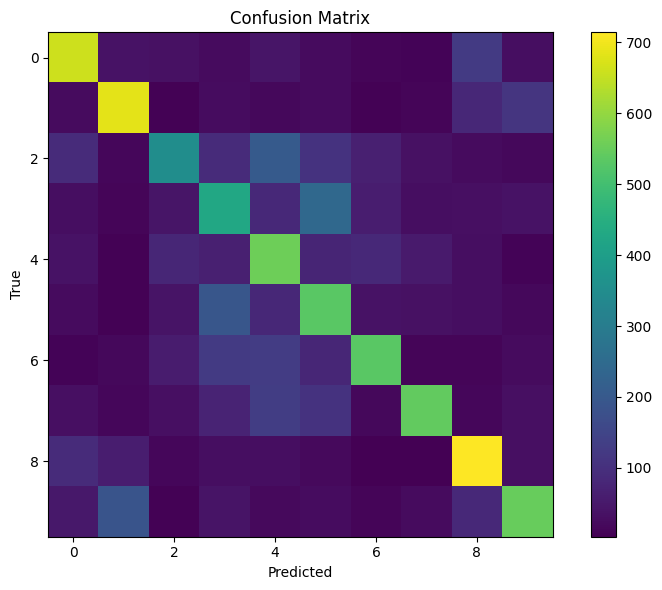

In [12]:
from evaluation.confusion_matrix import generate_confusion_matrix, plot_confusion_matrix

ann_cm = generate_confusion_matrix(ann_model, device)
print("Plotting ANN confusion matrix...")
plot_confusion_matrix(ann_cm, save_path="results/plots/ann_confusion_matrix.png")



 Confusion matrix for CNN Advanced (PyTorch)


Plotting CNN Advanced confusion matrix...
Confusion matrix saved to: results/plots/cnn_adv_confusion_matrix.png


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

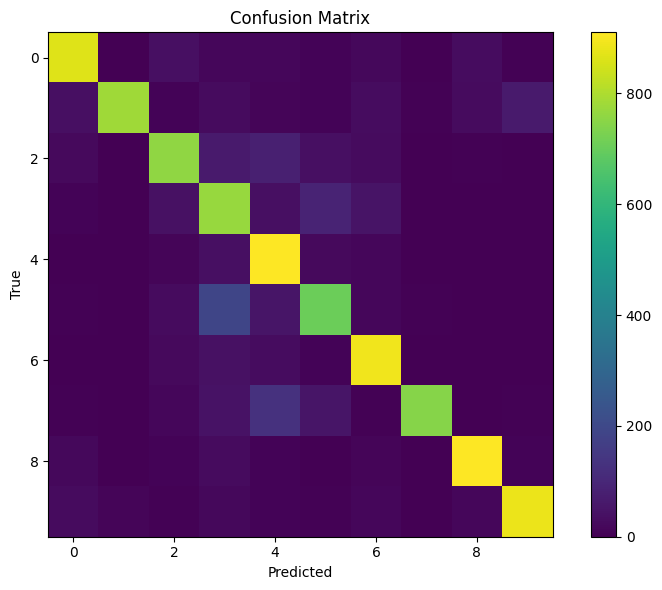

In [13]:
cnn_adv_cm = generate_confusion_matrix(cnn_adv, device)
print("Plotting CNN Advanced confusion matrix...")
plot_confusion_matrix(cnn_adv_cm, save_path="results/plots/cnn_adv_confusion_matrix.png")



Confusion matrix for CNN (TensorFlow)


Plotting CNN confusion matrix...
Confusion matrix saved to: results/plots/cnn_confusion_matrix.png


(<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>,
 array([[428, 222,  29,  94,   5,  34,  36,   1,  26, 125],
        [  4, 858,   0,  36,   0,   3,  15,   1,   0,  83],
        [ 70, 140, 152, 305,   3,  80, 154,  18,   4,  74],
        [ 34,  93,  15, 540,   2, 147,  66,  17,   1,  85],
        [ 33,  98,  32, 387,  22,  44, 283,  30,   2,  69],
        [ 14,  85,   8, 327,   1, 441,  66,  13,   0,  45],
        [ 16, 116,  10, 166,   0,  46, 592,   2,   1,  51],
        [ 26, 109,   7, 248,   5, 147,  81, 248,   1, 128],
        [ 62, 398,   6, 103,   2,  13,  15,   2, 199, 200],
        [ 16, 194,   1,  53,   0,  15,  13,   0,   1, 707]]))

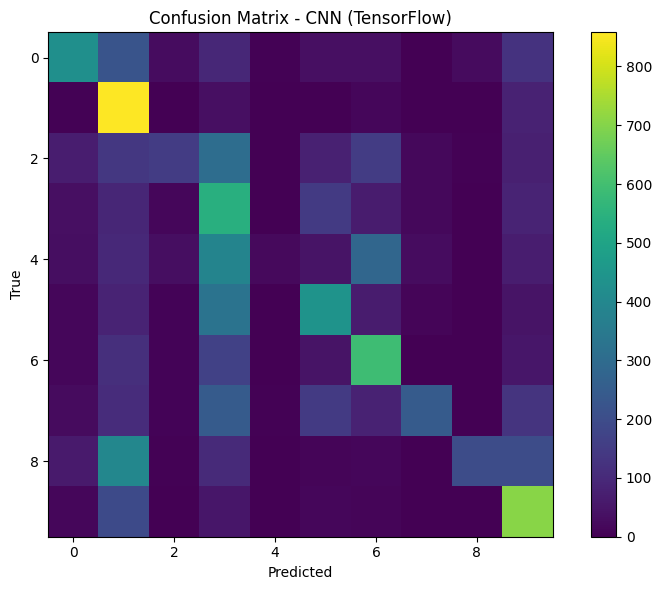

In [14]:
print("Plotting CNN confusion matrix...")
plot_tf_confusion_matrix(cnn_model, X_test_tf, y_test_np, save_path="results/plots/cnn_confusion_matrix.png")

### CIFAR-10 Class Labels:

The confusion matrices above use the following class indices:

| Index | Class Name |
|-------|------------|
| 0 | Airplane |
| 1 | Automobile |
| 2 | Bird |
| 3 | Cat |
| 4 | Deer |
| 5 | Dog |
| 6 | Frog |
| 7 | Horse |
| 8 | Ship |
| 9 | Truck |

**Interpretation:** Each cell (i,j) shows how many test images from true class i were predicted as class j. Perfect classification would show non-zero values only on the diagonal.

### comparison bar chart :

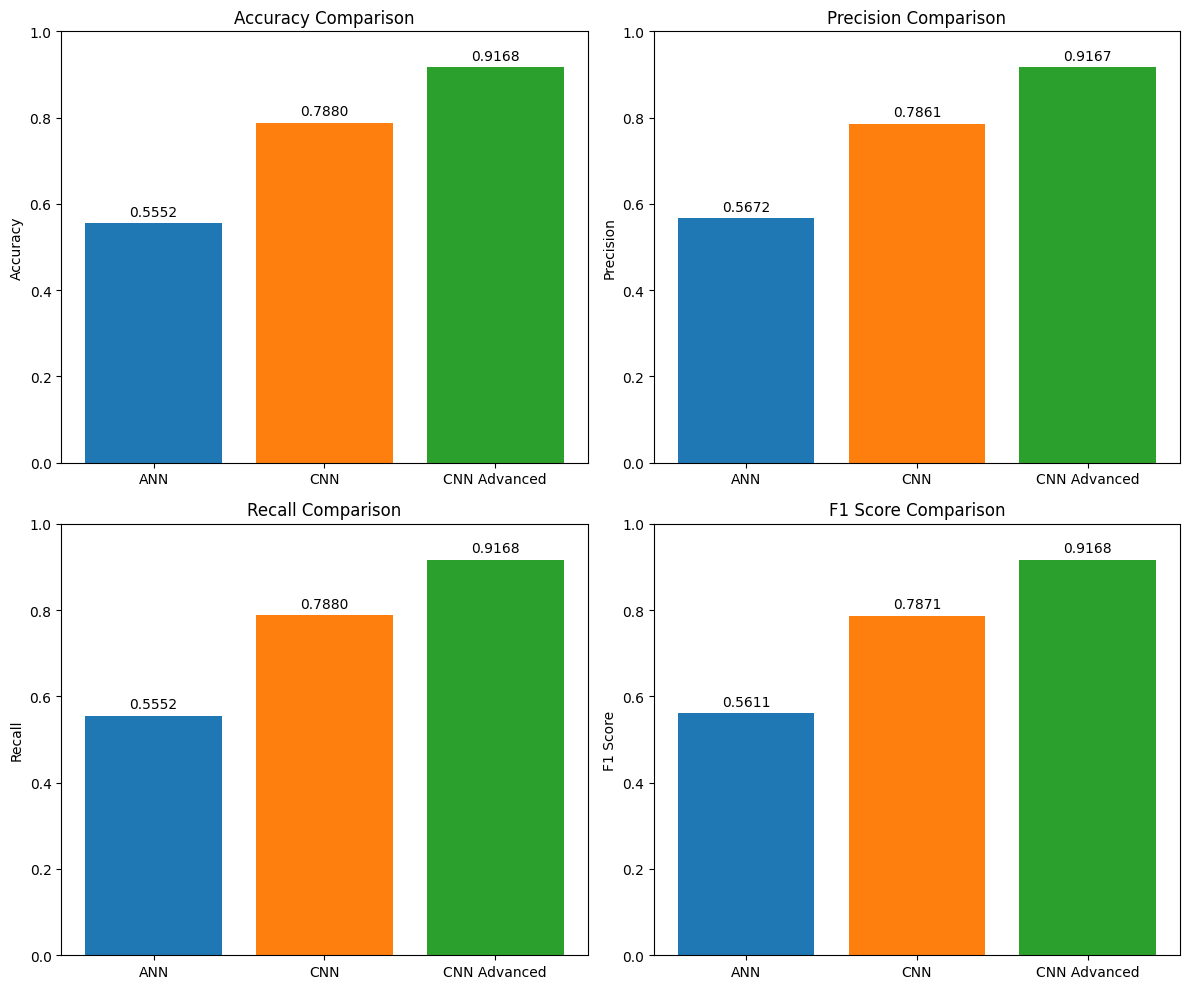


FINAL MODEL COMPARISON SUMMARY
Model           Accuracy     Precision    Recall       F1 Score    
------------------------------------------------------------
ANN             0.5552       0.5672       0.5552       0.5611      
CNN             0.7880       0.7861       0.7880       0.7871      
CNN Advanced    0.9168       0.9167       0.9168       0.9168      


In [15]:
# Collect all results
models = ['ANN', 'CNN', 'CNN Advanced']
accuracies = [
    ann_results['accuracy'],
    cnn_results['accuracy'],
    cnn_adv_results['accuracy']
]
precisions = [
    ann_results['precision'],
    cnn_results['precision'],
    cnn_adv_results['precision']
]
recalls = [
    ann_results['recall'],
    cnn_results['recall'],
    cnn_adv_results['recall']
]
f1_scores = [
    ann_results['f1'],
    cnn_results['f1'],
    cnn_adv_results['f1']
]

# Create comparison plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracies, precisions, recalls, f1_scores]

for idx, (ax, metric, vals) in enumerate(zip(axes.flat, metrics, values)):
    bars = ax.bar(models, vals, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)

    # Add value labels on bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('results/plots/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print("-" * 60)
print(f"{'ANN':<15} {ann_results['accuracy']:<12.4f} {ann_results['precision']:<12.4f} {ann_results['recall']:<12.4f} {ann_results['f1']:<12.4f}")
print(f"{'CNN':<15} {cnn_results['accuracy']:<12.4f} {cnn_results['precision']:<12.4f} {cnn_results['recall']:<12.4f} {cnn_results['f1']:<12.4f}")
print(f"{'CNN Advanced':<15} {cnn_adv_results['accuracy']:<12.4f} {cnn_adv_results['precision']:<12.4f} {cnn_adv_results['recall']:<12.4f} {cnn_adv_results['f1']:<12.4f}")

# CONCLUSION


In [16]:
print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

print(f"""
This experiment compared three neural network architectures on the CIFAR-10 dataset:

1. ANN (Artificial Neural Network): {ann_results['accuracy']:.2%} accuracy
   - Simple fully-connected network
   - Limited capability for spatial feature extraction

2. CNN (Convolutional Neural Network): {cnn_results['accuracy']:.2%} accuracy
   - Extracts spatial hierarchies through convolutions
   - {((cnn_results['accuracy'] - ann_results['accuracy']) * 100):.1f}% improvement over ANN

3. CNN Advanced: {cnn_adv_results['accuracy']:.2%} accuracy
   - Enhanced architecture with dropout and batch normalization
   - {((cnn_adv_results['accuracy'] - cnn_results['accuracy']) * 100):.1f}% improvement over basic CNN

KEY TAKEAWAY:
The Advanced CNN model outperformed both baseline models, achieving the highest
accuracy of {cnn_adv_results['accuracy']:.2%}. This validates that convolutional
architectures with proper regularization techniques are optimal for image
classification tasks like CIFAR-10.

CIFAR-10 CLASS MAPPING (for confusion matrices):
0: airplane    1: automobile    2: bird    3: cat    4: deer
5: dog         6: frog          7: horse   8: ship    9: truck

Note: Diagonal elements in confusion matrices show correct classifications.
Common confusions include cat↔dog, bird↔airplane, and deer↔horse.

All results and visualizations have been saved to the 'results/plots/' directory.
""")


CONCLUSION

This experiment compared three neural network architectures on the CIFAR-10 dataset:

1. ANN (Artificial Neural Network): 55.52% accuracy
   - Simple fully-connected network
   - Limited capability for spatial feature extraction

2. CNN (Convolutional Neural Network): 78.80% accuracy
   - Extracts spatial hierarchies through convolutions
   - 23.3% improvement over ANN

3. CNN Advanced: 91.68% accuracy
   - Enhanced architecture with dropout and batch normalization
   - 12.9% improvement over basic CNN

KEY TAKEAWAY:
The Advanced CNN model outperformed both baseline models, achieving the highest 
accuracy of 91.68%. This validates that convolutional 
architectures with proper regularization techniques are optimal for image 
classification tasks like CIFAR-10.

CIFAR-10 CLASS MAPPING (for confusion matrices):
0: airplane    1: automobile    2: bird    3: cat    4: deer
5: dog         6: frog          7: horse   8: ship    9: truck

Note: Diagonal elements in confusion matri